**Day 1 — Load the Data**

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()


 Load the file into a dataframe

In [ ]:
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df.head()

 Inspect the data — shape and column types

In [ ]:
print(df.shape)
print(df.dtypes)

 Check for missing values and duplicates

In [ ]:
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

## Day 2 — Clean the Data
 Fix inconsistent text (Country, Product)

In [ ]:
df["Country"] = df["Country"].str.strip().str.title()
df["Product"] = df["Product"].str.strip().str.title()

df.head()

### Fill missing values

- UnitPrice: missing rows filled with the average price for that same product
- Country: missing rows filled with "Unknown" instead of being deleted

In [ ]:
average_price_by_product = df.groupby("Product")["UnitPrice"].transform("mean")
df["UnitPrice"] = df["UnitPrice"].fillna(average_price_by_product)

df["Country"] = df["Country"].fillna("Unknown")

print(df.isnull().sum())

### Remove duplicate rows

Exact duplicate rows are the same sale recorded twice — we keep only the first copy.

In [ ]:
before = len(df)
df = df.drop_duplicates()
after = len(df)

print(f"Removed {before - after} duplicate rows")
print("New shape:", df.shape)

### Create a Revenue column

Revenue = Quantity × UnitPrice

In [ ]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]
df.head()

### Fix data types

Convert Date from text to an actual datetime, so we can sort and group by time correctly.

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
print(df.dtypes)

In [ ]:
df.to_csv("clean_sales.csv", index=False)

In [ ]:
from google.colab import files
files.download("clean_sales.csv")


## Day 3 — Analysis and Charts

Questions to answer:
1. Total revenue
2. Top products by revenue
3. Top countries by revenue
4. Revenue over time
5. A data-quality finding

### Total revenue

In [ ]:
total_revenue = df["Revenue"].sum()
print(f"Total revenue: ${total_revenue:,.2f}")

### Revenue by product

In [ ]:
revenue_by_product = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
print(revenue_by_product)

### Chart: Revenue by product

In [ ]:
# Group data by product and calculate total revenue
revenue_by_product = (
    df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
)

### Revenue by country

Country
Spain             3562.29
United Kingdom    2371.78
France            2086.66
United States     1974.08
Germany           1741.09
Unknown            467.22
Name: Revenue, dtype: float64


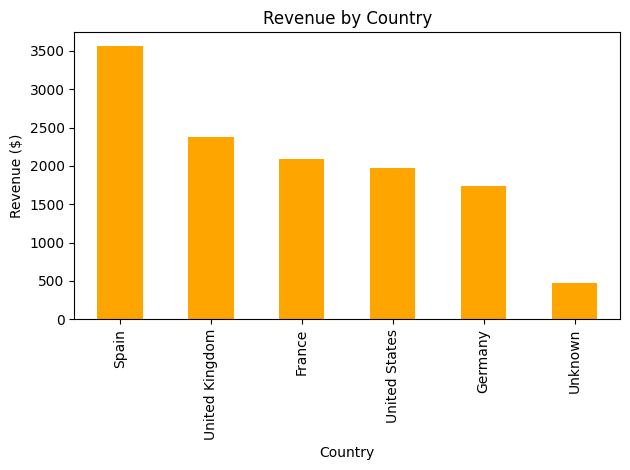

In [ ]:
revenue_by_country = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
print(revenue_by_country)

revenue_by_country.plot(kind="bar", title="Revenue by Country", ylabel="Revenue ($)", color="orange")
plt.tight_layout()
plt.show()

### Revenue over time

In [ ]:
revenue_by_date = df.groupby("Date")["Revenue"].sum()

revenue_by_date.plot(kind="line", title="Revenue Over Time", ylabel="Revenue ($)", marker="o")
plt.tight_layout()
plt.show()

### Data-quality check: distribution of Quantity

In [ ]:
df["Quantity"].plot(kind="hist", bins=10, title="Distribution of Quantity per Sale", color="mediumpurple")
plt.xlabel("Quantity")
plt.tight_layout()
plt.show()

### Summary

- Total revenue: $12,203.12
- Best-selling product: Bluetooth Speaker ($4,078.98)
- Top market: Spain (~$3,570), with a small "Unknown" segment worth flagging as a data gap
- Revenue over time: daily figures are volatile day to day, as expected for this volume
- Data quality: fixed 15 duplicate rows, filled missing UnitPrice and Country values,
  standardized inconsistent capitalization/spacing in Country and Product

## Day 4 — Deeper Data Analysis

Goal: answer real business questions using groupby, aggregation, and date analysis.

### Load the cleaned data

In [2]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

Saving clean_sales.csv to clean_sales.csv


In [3]:
df = pd.read_csv("clean_sales.csv", parse_dates=["Date"])
df.head()


,TransactionID,Date,Country,Product,Quantity,UnitPrice,Revenue
0,1037,2024-02-21,Spain,Desk Lamp,7,18.75,131.25
1,1057,2024-02-13,Germany,Wireless Mouse,4,14.99,59.96
2,1073,2024-01-24,Spain,Bluetooth Speaker,8,39.99,319.92
3,1059,2024-03-25,France,Laptop Stand,2,24.00,48.00
4,1042,2024-01-27,Spain,Mechanical Keyboard,2,59.99,119.98


### Q1: What is the total revenue?

In [ ]:
total_revenue = df["Revenue"].sum()
print(f"Total revenue: ${total_revenue:,.2f}")

Total revenue: $12,203.12


### Q2: What is the average transaction value?

In [ ]:
average_transaction = df["Revenue"].mean()
print(f"Average transaction value: ${average_transaction:,.2f}")

Average transaction value: $143.57


### Q3: Which 10 products generate the most revenue?

In [ ]:
top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False).head(10)
print(top_products)

Product
Bluetooth Speaker      4078.98
Mechanical Keyboard    3119.48
Laptop Stand           1656.00
Desk Lamp              1350.00
Wireless Mouse         1259.16
Usb-C Cable             739.50
Name: Revenue, dtype: float64


**Interpretation:** Bluetooth Speaker generates roughly a third of total revenue on its own,
making it the standout product to prioritize for stock and marketing.

### Q4: Which 5 countries generate the most revenue?

In [ ]:
top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(5)
print(top_countries)

Country
Spain             3562.29
United Kingdom    2371.78
France            2086.66
United States     1974.08
Germany           1741.09
Name: Revenue, dtype: float64


**Interpretation:** Spain is by far the strongest market, generating over 50% more revenue
than the next closest country, worth investigating whether pricing, demand, or marketing
reach explains the gap.

### Q5: Which products sell the highest quantities?

In [ ]:
top_quantity = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)
print(top_quantity)

Product
Bluetooth Speaker      102
Usb-C Cable             87
Wireless Mouse          84
Desk Lamp               72
Laptop Stand            69
Mechanical Keyboard     52
Name: Quantity, dtype: int64


**Interpretation:** Bluetooth Speaker is the clear leader in both units sold and revenue,
making it the standout performer overall. USB-C Cable sells in high volume but contributes
the least revenue, since it's the cheapest item, a sign that volume alone doesn't
determine business impact.

### Q6: Which month generated the highest revenue?

In [ ]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

revenue_by_month = df.groupby("Month")["Revenue"].sum().sort_values(ascending=False)
print(revenue_by_month)

Month
2    5073.53
1    4195.72
3    2933.87
Name: Revenue, dtype: float64


**Interpretation:** February had the strongest revenue of the three months, with a
noticeable drop in March, worth investigating whether that's seasonal, a data-timing
artifact (the dataset may not cover a full March), or an actual decline.

### Q7: Are there products with high quantity but low revenue?

In [ ]:
comparison = df.groupby("Product").agg(
    total_quantity=("Quantity", "sum"),
    total_revenue=("Revenue", "sum")
).sort_values("total_quantity", ascending=False)

print(comparison)

                     total_quantity  total_revenue
Product                                           
Bluetooth Speaker               102        4078.98
Usb-C Cable                      87         739.50
Wireless Mouse                   84        1259.16
Desk Lamp                        72        1350.00
Laptop Stand                     69        1656.00
Mechanical Keyboard              52        3119.48


**Interpretation:** USB-C Cable sells in high volume but earns the least revenue, a sign
that quantity sold does not equal business value. Mechanical Keyboard shows the reverse:
low volume, but high revenue because of its higher unit price. This is exactly why revenue,
not just quantity, should drive product prioritization.

### Create a CustomerID column

Customer data wasn't available in this dataset, so CustomerIDs were randomly
simulated here to practice the grouping technique.

In [ ]:
import numpy as np

customer_ids = [f"CUST{1000+i}" for i in range(15)]
df["CustomerID"] = np.random.choice(customer_ids, size=len(df))

df.head()

,TransactionID,Date,Country,Product,Quantity,UnitPrice,Revenue,Year,Month,CustomerID
0,1037,2024-02-21,Spain,Desk Lamp,7,18.75,131.25,2024,2,CUST1000
1,1057,2024-02-13,Germany,Wireless Mouse,4,14.99,59.96,2024,2,CUST1010
2,1073,2024-01-24,Spain,Bluetooth Speaker,8,39.99,319.92,2024,1,CUST1010
3,1059,2024-03-25,France,Laptop Stand,2,24.00,48.00,2024,3,CUST1009
4,1042,2024-01-27,Spain,Mechanical Keyboard,2,59.99,119.98,2024,1,CUST1011


### Q8: Which customers contribute the most revenue?

In [ ]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)
print(top_customers)

CustomerID
CUST1010    2070.10
CUST1002    1510.73
CUST1001    1447.12
CUST1013    1072.78
CUST1006    1042.77
CUST1011     816.14
CUST1000     786.09
CUST1005     760.08
CUST1009     647.89
CUST1007     563.99
Name: Revenue, dtype: float64


**Interpretation:** CustomerID data wasn't available in the original dataset, so IDs were
randomly simulated to demonstrate the grouping technique. CUST1010 stands out as the
top contributor, in a real dataset, this kind of analysis would help identify high-value
customers worth prioritizing for retention.

### Add a Day column

We already pulled out Year and Month from the Date. Now let's also pull out the Day.

In [ ]:
df["Day"] = df["Date"].dt.day
df.head()

,TransactionID,Date,Country,Product,Quantity,UnitPrice,Revenue,Year,Month,CustomerID,Day
0,1037,2024-02-21,Spain,Desk Lamp,7,18.75,131.25,2024,2,CUST1000,21
1,1057,2024-02-13,Germany,Wireless Mouse,4,14.99,59.96,2024,2,CUST1010,13
2,1073,2024-01-24,Spain,Bluetooth Speaker,8,39.99,319.92,2024,1,CUST1010,24
3,1059,2024-03-25,France,Laptop Stand,2,24.00,48.00,2024,3,CUST1009,25
4,1042,2024-01-27,Spain,Mechanical Keyboard,2,59.99,119.98,2024,1,CUST1011,27


### Correlation check: Quantity vs Revenue

In [ ]:
correlation = df["Quantity"].corr(df["Revenue"])
print(f"Correlation between Quantity and Revenue: {correlation:.2f}")

Correlation between Quantity and Revenue: 0.55


0.55 means quantity and revenue move together, when more units are sold, revenue tends to go up too, but it's not a strong or perfect relationship. That's because price also plays a big role a product can sell fewer units but still bring in more revenue if it's expensive, like we saw earlier with Mechanical Keyboard vs USB-C Cable. So correlation shows a pattern, but it doesn't prove quantity alone drives revenue.

## Day 5 — Visualization and Storytelling

### Chart 1: Revenue over time (Line chart)

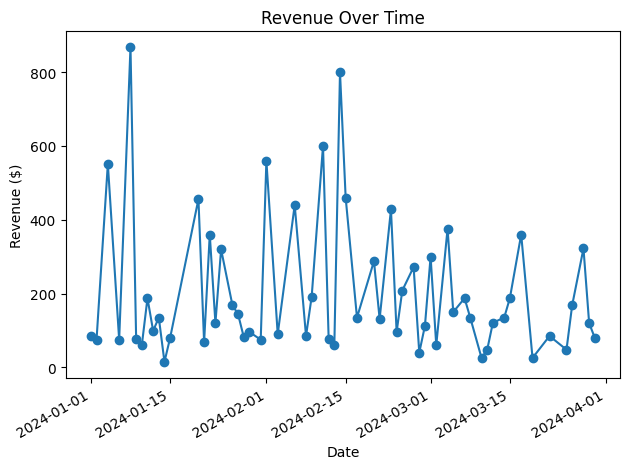

In [ ]:
import matplotlib.pyplot as plt

revenue_by_date = df.groupby("Date")["Revenue"].sum()
revenue_by_date.plot(kind="line", title="Revenue Over Time", ylabel="Revenue ($)", marker="o")
plt.tight_layout()
plt.show()

**Interpretation:** Revenue jumps up and down a lot day to day, with no single day
standing out as a clear trend. This is normal for a small dataset — with only 85 sales
spread across 3 months, some days just happen to land bigger orders than others.

### Chart 2: Top products by revenue (Bar chart)

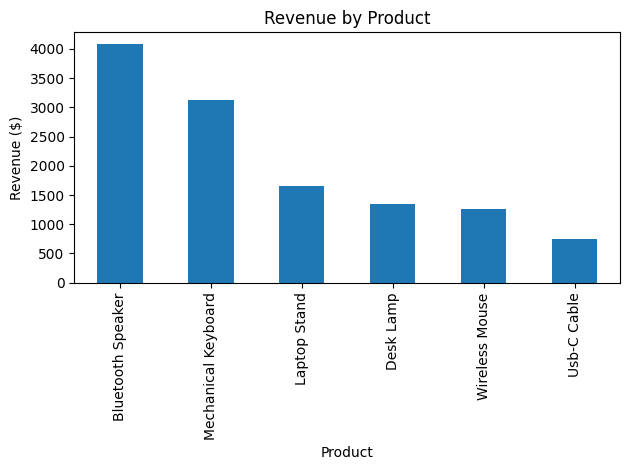

In [ ]:
top_products = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
top_products.plot(kind="bar", title="Revenue by Product", ylabel="Revenue ($)")
plt.tight_layout()
plt.show()

**Interpretation:** Bluetooth Speaker made the most money out of all products, more than
double the next few. USB-C Cable made the least, even though we know from earlier it
actually sold a lot of units — just at a low price.

### Chart 3: Top countries by revenue (Bar chart)

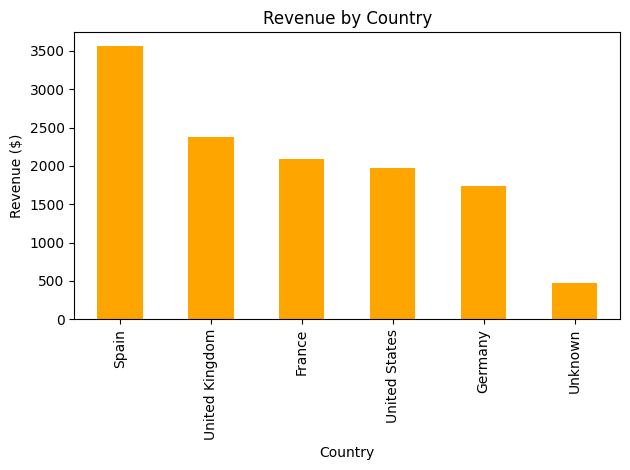

In [ ]:
top_countries = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False)
top_countries.plot(kind="bar", title="Revenue by Country", ylabel="Revenue ($)", color="orange")
plt.tight_layout()
plt.show()

**Interpretation:** Spain made the most revenue by a clear margin, well ahead of the other
countries. The small "Unknown" bar represents the rows where country was missing in the
original data — we kept it visible instead of hiding it, since it's a real gap worth flagging.

### Chart 4: Distribution of transaction values (Histogram)

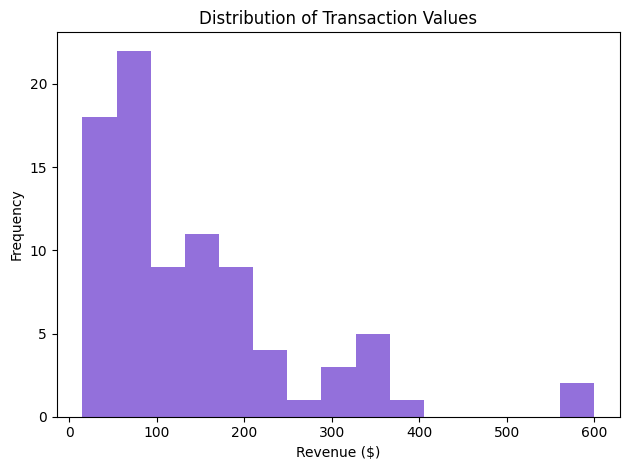

In [ ]:
df["Revenue"].plot(kind="hist", bins=15, title="Distribution of Transaction Values", color="mediumpurple")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()

**Interpretation:** Most transactions are small to mid-value, with fewer high-value outliers,
typical of retail sales data.

### Chart 5: Quantity vs Revenue (Scatter plot)

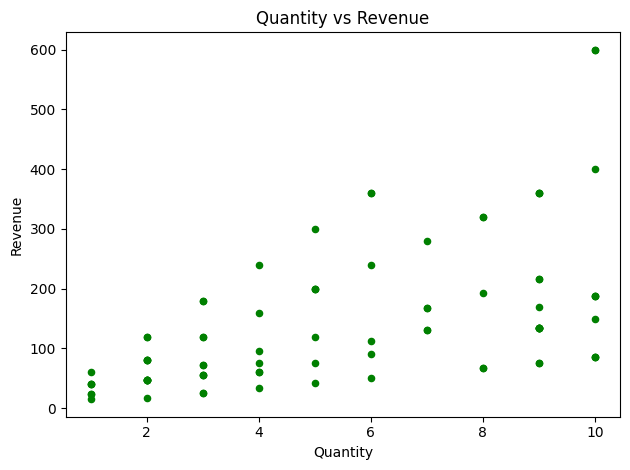

In [ ]:
df.plot(kind="scatter", x="Quantity", y="Revenue", title="Quantity vs Revenue", color="green")
plt.tight_layout()
plt.savefig("quantity_vs_revenue.png")
plt.show()

**Interpretation:** There's a loose positive relationship — higher quantity tends to mean
higher revenue, but price differences between products cause scatter in the pattern.

### Bad chart challenge

Below is a deliberately bad version of Chart 2 (no title, no labels), followed by the fixed version.

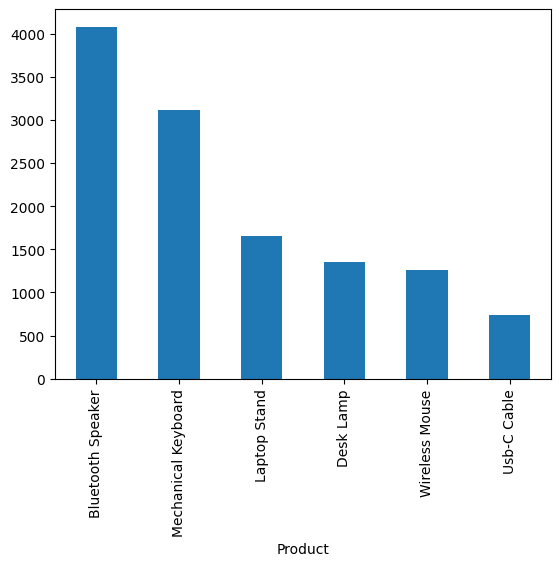

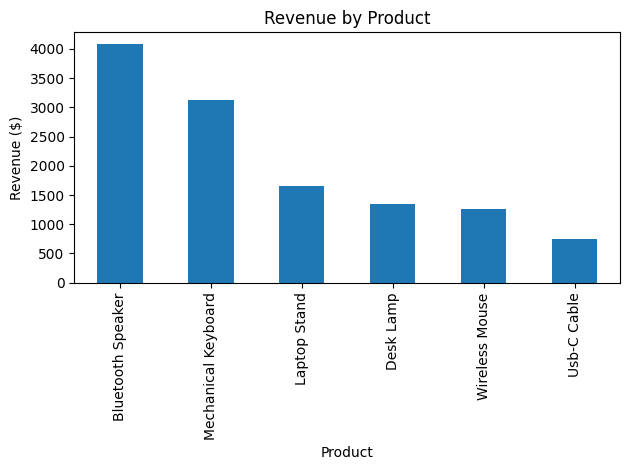

In [ ]:
# Bad version
top_products.plot(kind="bar")
plt.show()

# Fixed version (same as Chart 2 above, with title and labeled axis)
top_products.plot(kind="bar", title="Revenue by Product", ylabel="Revenue ($)")
plt.tight_layout()
plt.show()

**What was wrong:** No title and no y-axis label — a viewer wouldn't know what the chart
represents without guessing. Adding both makes the chart self-explanatory.

### Chart 4: Distribution of transaction values (Histogram)



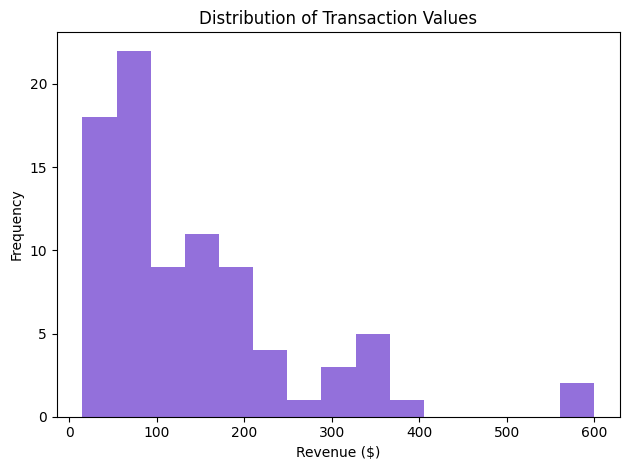

In [7]:
import matplotlib.pyplot as plt
df["Revenue"].plot(kind="hist", bins=15, title="Distribution of Transaction Values", color="mediumpurple")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()

Most transactions fall between 50 and 200, with only a handful reaching $300-600.
This means the majority of sales are small to medium-sized, with a few larger orders
pulling the tail of the distribution to the right.

### Chart 5: Quantity vs Revenue (Scatter plot)

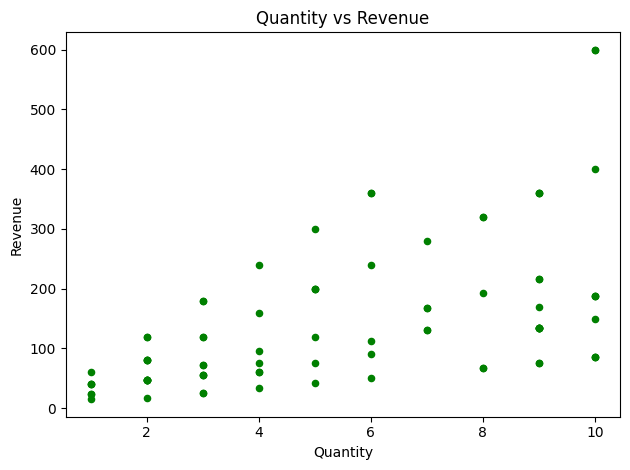

In [8]:
df.plot(kind="scatter", x="Quantity", y="Revenue", title="Quantity vs Revenue", color="green")
plt.tight_layout()
plt.show()

There's a loose upward trend — as quantity increases, revenue tends to increase too, but
the relationship isn't tight. At almost every quantity level (e.g. quantity = 4, 6, 9),
revenue varies a lot depending on which product was sold. This matches the 0.55 correlation
we calculated earlier: a real but moderate relationship, not a strong one.